In [8]:
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt


In [9]:
# --- Physical constants ---
L = 1.0          # Length (m)
alpha = 0.01     # Thermal diffusivity (m²/s)
T0 = 100.0       # Left boundary (°C)


In [10]:
# --- Sampling parameters ---
TL_values = np.linspace(20, 200, 30)       # Right boundary temperatures
t_values = np.linspace(0, 5, 50)           # Time values (s)
x_points = np.array([0.0, L/4, L/2, 3*L/4, L])         # Observation points


In [4]:
# --- Function for transient analytical solution ---
def temperature_transient(x, t, T0, TL, L, alpha, N_terms=100):
    # steady part
    steady = T0 + (TL - T0) * x / L
    # transient Fourier series
    series = 0.0
    for n in range(1, N_terms + 1):
        A_n = 2 * (T0 - TL) * (1 - (-1)**n) / (n * np.pi)
        series += A_n * np.sin(n * np.pi * x / L) * np.exp(-alpha * (n * np.pi / L)**2 * t)
    return steady + series


In [5]:
# --- Generate dataset ---
records = []
for TL in TL_values:
    for t in t_values:
        temps = [temperature_transient(x, t, T0, TL, L, alpha) for x in x_points]
        records.append((t, *temps))

# --- Convert to Arrow table ---
table = pa.Table.from_pylist([
    {"t": r[0], "T_0": r[1], "T_L/4": r[2], "T_L/2": r[3], "T_3L/4": r[4], "T_L": r[5], "case_id": int(i/len(t_values))}
    for i, r in enumerate(records)
])


In [6]:
# --- Save to Parquet ---
pq.write_table(table, "dataset/transient_heat_data.parquet")
print("✅ Data saved to transient_heat_data.parquet")


✅ Data saved to transient_heat_data.parquet


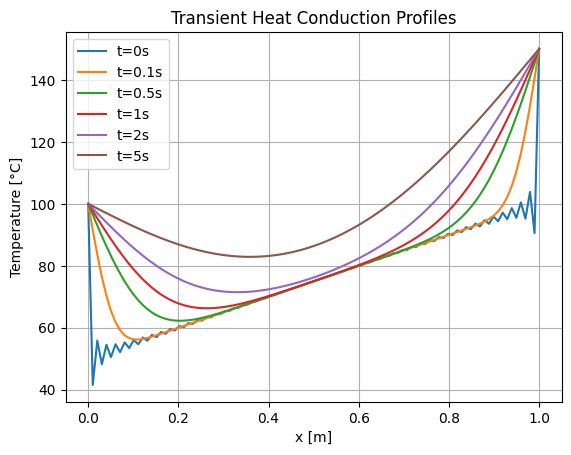

In [7]:
# --- Plot example evolution ---
example_TL = 150.0
temps_over_time = [
    [temperature_transient(x, t, T0, example_TL, L, alpha) for x in np.linspace(0, L, 100)]
    for t in [0, 0.1, 0.5, 1, 2, 5]
]
for i, T_profile in enumerate(temps_over_time):
    plt.plot(np.linspace(0, L, 100), T_profile, label=f"t={ [0,0.1,0.5,1,2,5][i] }s")

plt.xlabel("x [m]")
plt.ylabel("Temperature [°C]")
plt.title("Transient Heat Conduction Profiles")
plt.legend()
plt.grid(True)
plt.show()
